In [1]:
# CELDA 1: Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import psycopg2
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [2]:
# CELDA 2: Conexión a PostgreSQL y carga de datos
conn = psycopg2.connect(
    host='localhost', port=5432,
    database='divisas_db', user='etl_user', password='etl1234'
)

query = """
SELECT 
    moneda_destino,
    tasa_cambio,
    inversa,
    variacion_pct,
    volatilidad_7d,
    fecha_extraccion,
    fecha_actualizacion_api
FROM tasas_cambio
WHERE fecha_actualizacion_api = 'simulado'
ORDER BY fecha_extraccion ASC
"""

df = pd.read_sql(query, conn)
conn.close()

df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])
df['dia'] = (df['fecha_extraccion'] - df['fecha_extraccion'].min()).dt.days

print(f"✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n🏙️  Monedas disponibles:")
print(df['moneda_destino'].value_counts())
df.head()

✅ Datos cargados desde PostgreSQL
   Filas    : 1,000
   Columnas : 8

🏙️  Monedas disponibles:
moneda_destino
EUR    125
COP    125
GBP    125
JPY    125
BRL    125
MXN    125
CAD    125
AUD    125
Name: count, dtype: int64


,moneda_destino,tasa_cambio,inversa,variacion_pct,volatilidad_7d,fecha_extraccion,fecha_actualizacion_api,dia
0,EUR,0.839169,1.191655,-2.444907,0.021031,2025-12-19 00:16:59.756857,simulado,0
1,COP,3766.745886,0.000265,0.363857,13.655886,2025-12-19 00:16:59.756857,simulado,0
2,GBP,0.740860,1.349783,-0.475605,0.003540,2025-12-19 00:16:59.756857,simulado,0
3,JPY,155.793719,0.006419,-1.333934,2.106281,2025-12-19 00:16:59.756857,simulado,0
4,BRL,5.177812,0.193132,0.248053,0.012812,2025-12-19 00:16:59.756857,simulado,0


In [11]:
# CELDA 3: Estadísticas descriptivas
vars_num = ['tasa_cambio', 'inversa', 'variacion_pct', 'volatilidad_7d', 'dia']

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(df[vars_num].describe().round(4))

print("\n📊 Estadísticas por moneda (tasa_cambio):")
print(df.groupby('moneda_destino')['tasa_cambio'].agg(['mean','std','min','max']).round(4))

📊 ESTADÍSTICAS DESCRIPTIVAS
       tasa_cambio    inversa  variacion_pct  volatilidad_7d        dia
count    1000.0000  1000.0000      1000.0000       1000.0000  1000.0000
mean      492.1030     0.5263         0.0487         18.1065    62.0000
std      1233.8401     0.5042         1.4802         46.6131    36.1013
min         0.7270     0.0003        -2.4997          0.0011     0.0000
25%         1.2144     0.0433        -1.2633          0.0378    31.0000
50%         3.2395     0.4466         0.0587          0.0681    62.0000
75%        52.0067     0.8495         1.3135          0.8559    93.0000
max      3845.5928     1.3754         2.4993        182.9796   124.0000

📊 Estadísticas por moneda (tasa_cambio):
                     mean      std        min        max
moneda_destino                                          
AUD                1.4072   0.0203     1.3691     1.4391
BRL                5.1655   0.0779     5.0399     5.2933
CAD                1.3603   0.0213     1.3253     1.39

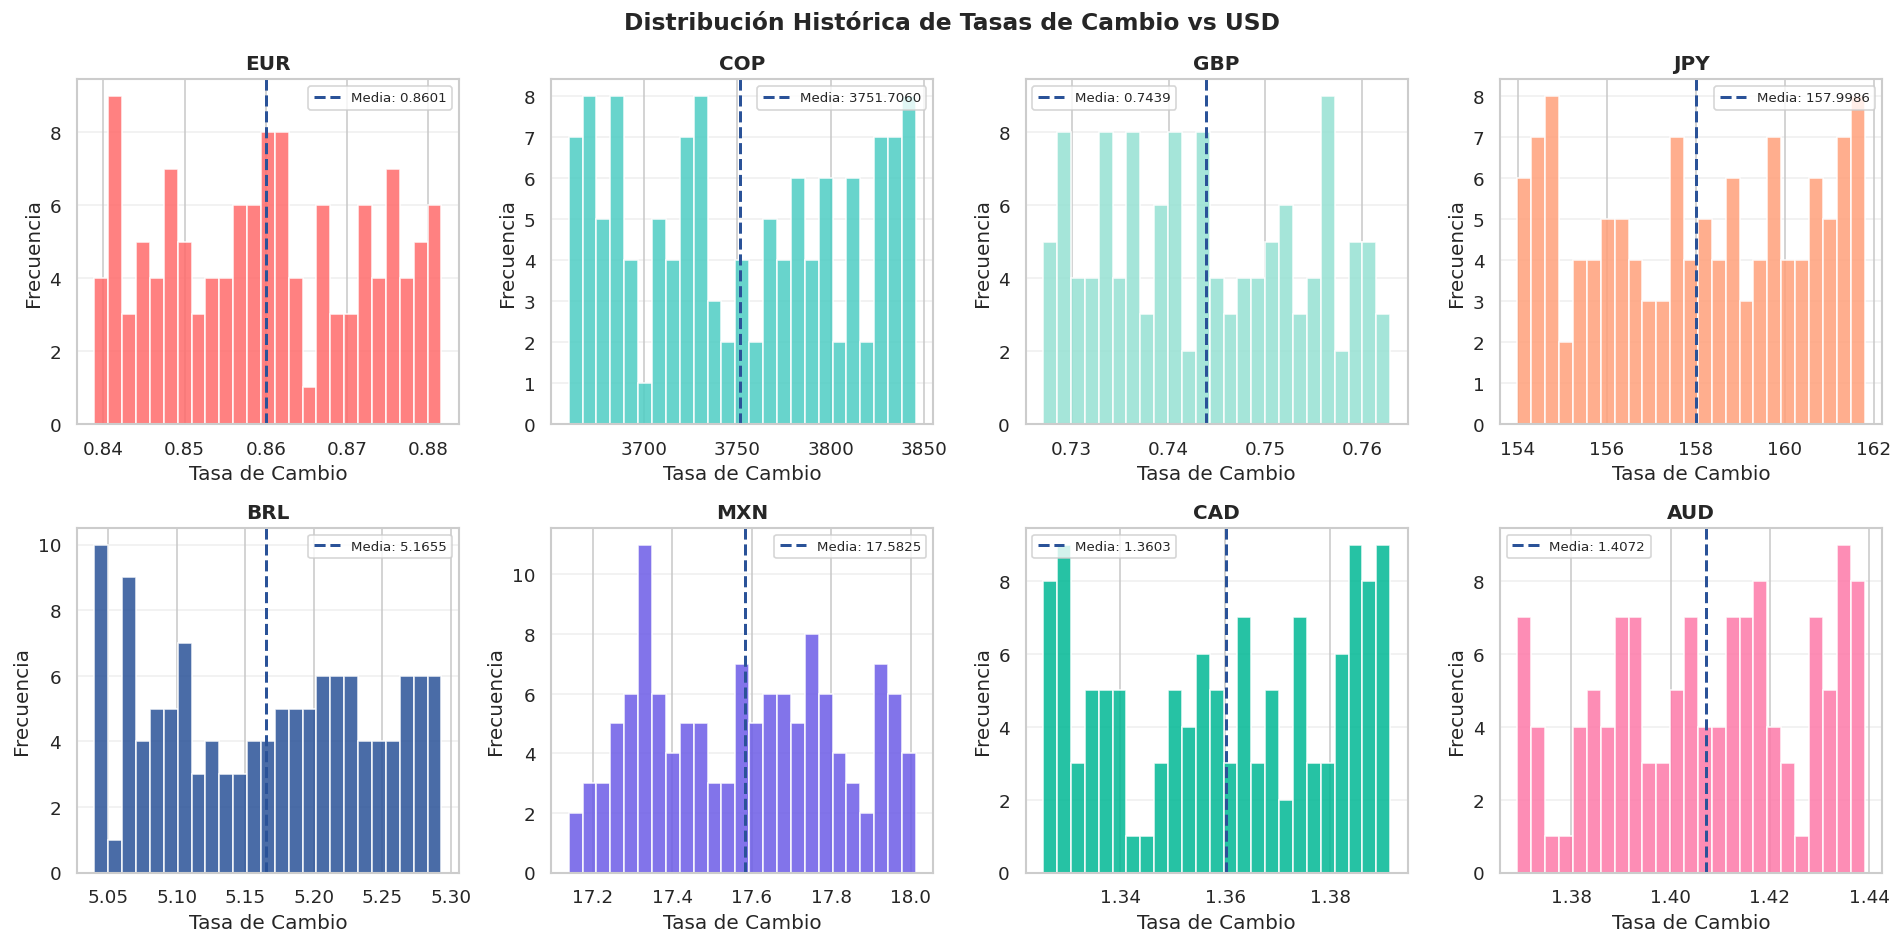

✅ Gráfica guardada en data/eda_distribuciones.png


In [4]:
# CELDA 4: Distribución histórica por moneda
monedas = df['moneda_destino'].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución Histórica de Tasas de Cambio vs USD', fontsize=14, fontweight='bold')

colores = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a', '#2a5298', '#6c5ce7', '#00b894', '#fd79a8']

for idx, (moneda, color) in enumerate(zip(monedas, colores)):
    ax = axes[idx // 4][idx % 4]
    datos = df[df['moneda_destino'] == moneda]['tasa_cambio']
    ax.hist(datos, bins=25, color=color, edgecolor='white', alpha=0.85)
    media = datos.mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8, label=f'Media: {media:.4f}')
    ax.set_title(moneda, fontweight='bold')
    ax.set_xlabel('Tasa de Cambio')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en data/eda_distribuciones.png")


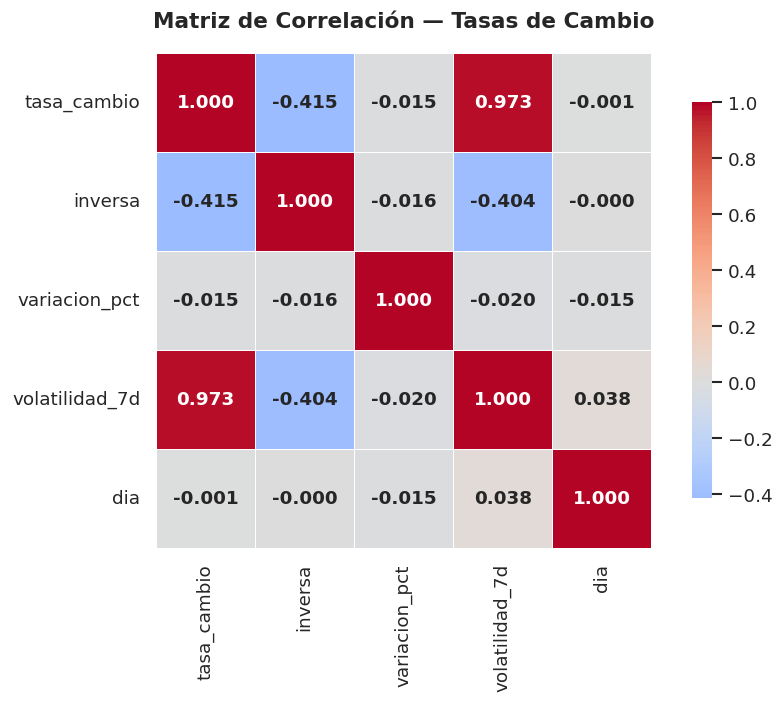


📊 Correlación con tasa_cambio:
volatilidad_7d    0.9729
dia              -0.0011
variacion_pct    -0.0153
inversa          -0.4152
Name: tasa_cambio, dtype: float64


In [12]:
# CELDA 5: Matriz de correlación
corr = df[['tasa_cambio', 'inversa', 'variacion_pct', 'volatilidad_7d', 'dia']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Matriz de Correlación — Tasas de Cambio', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('data/eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con tasa_cambio:")
print(corr['tasa_cambio'].drop('tasa_cambio').sort_values(ascending=False).round(4))

📈 REGRESIÓN LINEAL SIMPLE — EUR
   Train: 100 muestras | Test: 25 muestras

📐 Ecuación del modelo:
   tasa_cambio = 0.858403 + (0.000022 × dia)

📊 MÉTRICAS:
   R²   : -0.0068 (-0.68%)
   RMSE : 0.011301
   MAE  : 0.009462


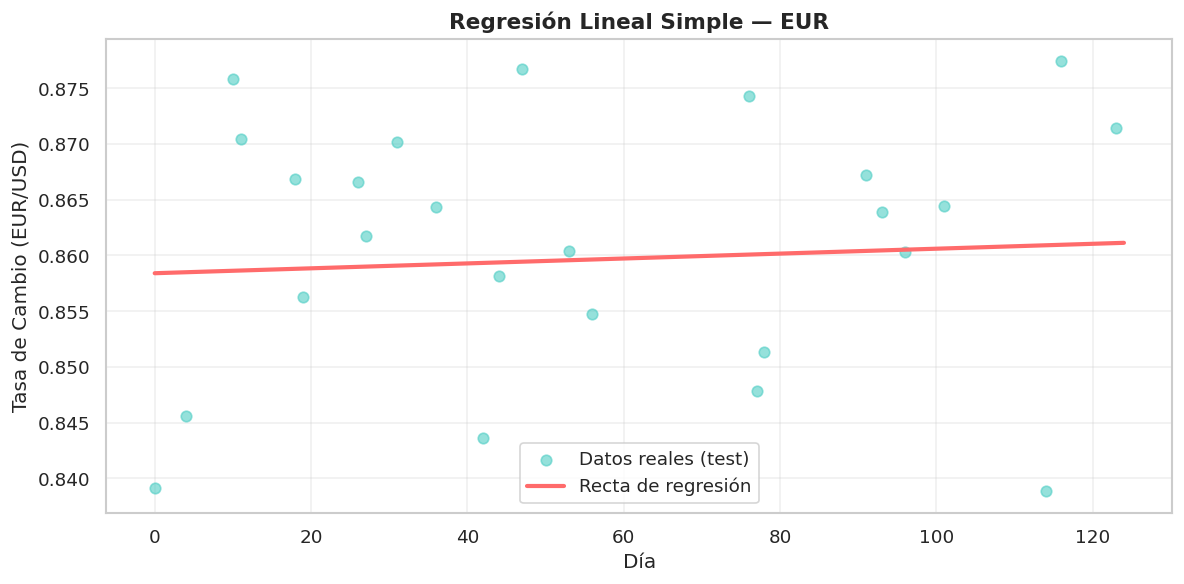

In [6]:
# CELDA 6: Regresión Lineal Simple (dia -> tasa_cambio para una moneda)
# Usamos EUR como ejemplo representativo
moneda_ejemplo = 'EUR'
datos_eur = df[df['moneda_destino'] == moneda_ejemplo].copy()

X_simple = datos_eur[['dia']].values
y = datos_eur['tasa_cambio'].values

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.20, random_state=42)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)
y_pred_simple = modelo_simple.predict(X_test)

print(f"📈 REGRESIÓN LINEAL SIMPLE — {moneda_ejemplo}")
print(f"   Train: {len(X_train)} muestras | Test: {len(X_test)} muestras")
print(f"\n📐 Ecuación del modelo:")
print(f"   tasa_cambio = {modelo_simple.intercept_:.6f} + ({modelo_simple.coef_[0]:.6f} × dia)")

# Métricas
r2   = r2_score(y_test, y_pred_simple)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_simple))
mae  = mean_absolute_error(y_test, y_pred_simple)

print(f"\n📊 MÉTRICAS:")
print(f"   R²   : {r2:.4f} ({r2*100:.2f}%)")
print(f"   RMSE : {rmse:.6f}")
print(f"   MAE  : {mae:.6f}")

# Gráfica
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X_test, y_test, alpha=0.6, color='#4ecdc4', label='Datos reales (test)', s=40)
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line), color='#ff6b6b', linewidth=2.5, label='Recta de regresión')
ax.set_xlabel('Día')
ax.set_ylabel(f'Tasa de Cambio ({moneda_ejemplo}/USD)')
ax.set_title(f'Regresión Lineal Simple — {moneda_ejemplo}', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

📈 REGRESIÓN LINEAL MÚLTIPLE — Todas las monedas
   Features: ['dia', 'inversa', 'variacion_pct', 'volatilidad_7d']

📐 Coeficientes:
   dia            : -1.3222
   inversa        : -62.2105
   variacion_pct  : 1.9342
   volatilidad_7d : 25.9098
   Intercepto    : 145.9079

📊 MÉTRICAS:
   R²   : 0.9590 (95.90%)
   RMSE : 256.8231
   MAE  : 121.9680


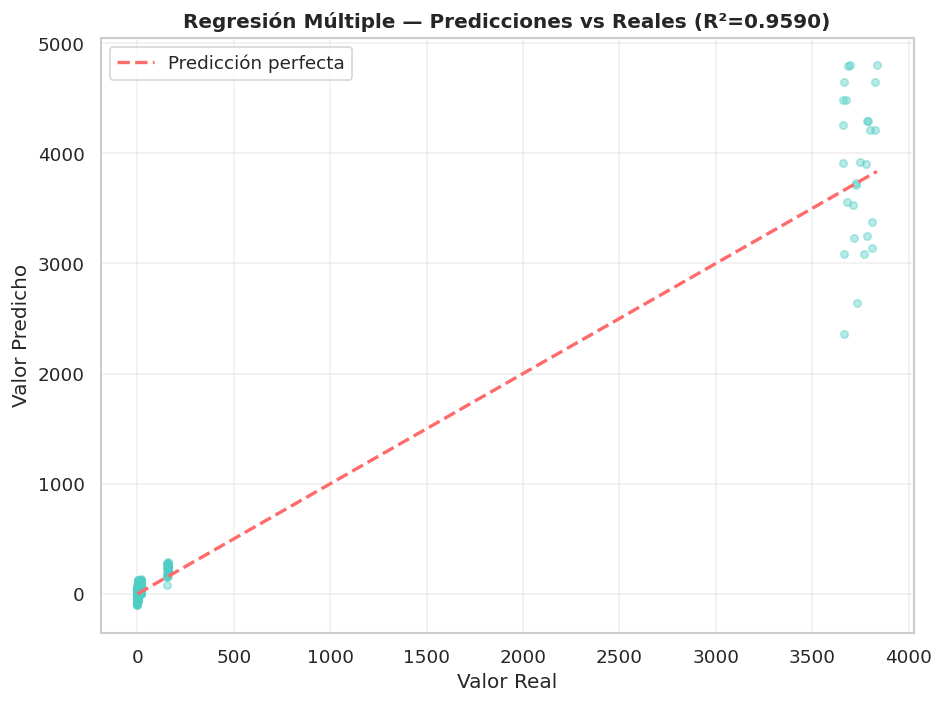

In [13]:
# CELDA 7: Regresión Lineal Múltiple
FEATURES = ['dia', 'inversa', 'variacion_pct', 'volatilidad_7d']

X_multi = df[FEATURES].values
y_multi = df['tasa_cambio'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_multi = modelo_multi.predict(X_test_m)

r2_m   = r2_score(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("📈 REGRESIÓN LINEAL MÚLTIPLE — Todas las monedas")
print(f"   Features: {FEATURES}")
print(f"\n📐 Coeficientes:")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"   {feat:15s}: {coef:.4f}")
print(f"   Intercepto    : {modelo_multi.intercept_:.4f}")
print(f"\n📊 MÉTRICAS:")
print(f"   R²   : {r2_m:.4f} ({r2_m*100:.2f}%)")
print(f"   RMSE : {rmse_m:.4f}")
print(f"   MAE  : {mae_m:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_m, y_pred_multi, alpha=0.4, color='#4ecdc4', s=20)
minval, maxval = y_test_m.min(), y_test_m.max()
ax.plot([minval, maxval], [minval, maxval], color='#ff6b6b', linewidth=2, linestyle='--', label='Predicción perfecta')
ax.set_xlabel('Valor Real')
ax.set_ylabel('Valor Predicho')
ax.set_title(f'Regresión Múltiple — Predicciones vs Reales (R²={r2_m:.4f})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/regresion_multiple.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# CELDA 8: OLS statsmodels + supuestos estadísticos
X_ols = sm.add_constant(df[FEATURES])
modelo_ols = sm.OLS(df['tasa_cambio'], X_ols).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            tasa_cambio   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     4579.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:34:35   Log-Likelihood:                -7053.5
No. Observations:                1000   AIC:                         1.412e+04
Df Residuals:                     995   BIC:                         1.414e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            142.0234     21.226      6.

🧪 TEST DE SHAPIRO-WILK (Normalidad de residuos)
   Estadístico : 0.4143
   p-valor     : 0.0000
   Conclusión  : ❌ Residuos NO normales (p ≤ 0.05)

🧪 TEST DE BREUSCH-PAGAN (Homocedasticidad)
   Estadístico : 55.6473
   p-valor     : 0.0000
   Conclusión  : ❌ Heterocedasticidad (p ≤ 0.05)

🧪 FACTOR DE INFLACIÓN DE VARIANZA (VIF)
   dia            : VIF = 1.9957 ✅ OK
   inversa        : VIF = 1.7766 ✅ OK
   variacion_pct  : VIF = 1.0007 ✅ OK
   volatilidad_7d : VIF = 1.2177 ✅ OK


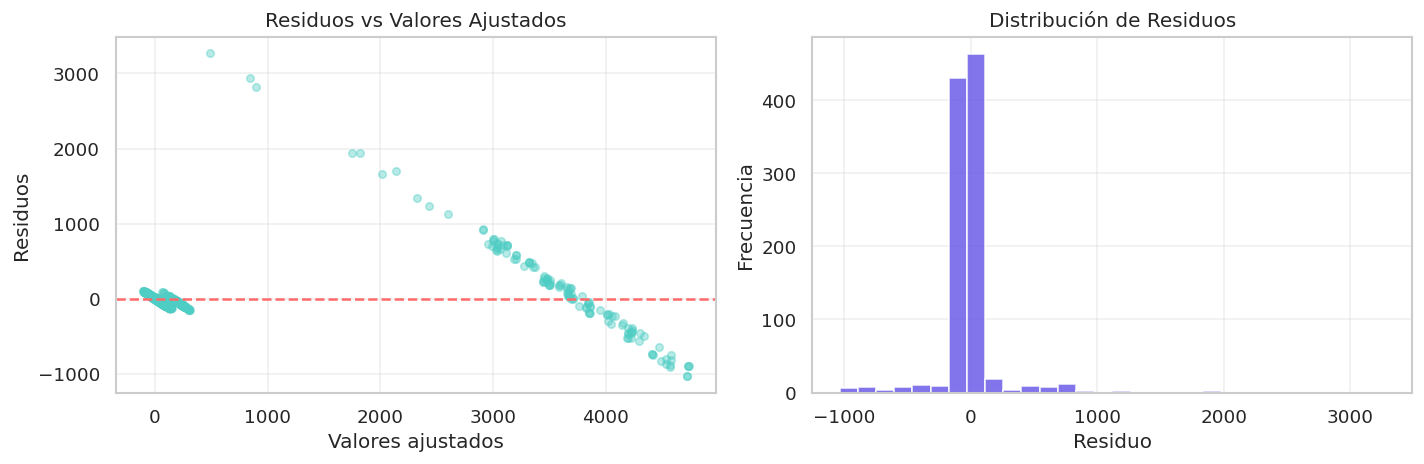

In [15]:
# CELDA 9: Tests de supuestos — Normalidad y Homocedasticidad
residuos = modelo_ols.resid

# Test de Shapiro-Wilk (normalidad)
stat_sw, p_sw = stats.shapiro(residuos[:200])
print("🧪 TEST DE SHAPIRO-WILK (Normalidad de residuos)")
print(f"   Estadístico : {stat_sw:.4f}")
print(f"   p-valor     : {p_sw:.4f}")
print(f"   Conclusión  : {'✅ Residuos normales (p > 0.05)' if p_sw > 0.05 else '❌ Residuos NO normales (p ≤ 0.05)'}")

# Test de Breusch-Pagan (homocedasticidad)
bp_test = het_breuschpagan(residuos, X_ols)
print(f"\n🧪 TEST DE BREUSCH-PAGAN (Homocedasticidad)")
print(f"   Estadístico : {bp_test[0]:.4f}")
print(f"   p-valor     : {bp_test[1]:.4f}")
print(f"   Conclusión  : {'✅ Homocedasticidad (p > 0.05)' if bp_test[1] > 0.05 else '❌ Heterocedasticidad (p ≤ 0.05)'}")

# VIF — Multicolinealidad
print(f"\n🧪 FACTOR DE INFLACIÓN DE VARIANZA (VIF)")
for i, col in enumerate(FEATURES):
    vif = variance_inflation_factor(df[FEATURES].values, i)
    print(f"   {col:15s}: VIF = {vif:.4f} {'✅ OK' if vif < 10 else '⚠️ Alta multicolinealidad'}")

# Gráfica de residuos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(modelo_ols.fittedvalues, residuos, alpha=0.4, color='#4ecdc4', s=20)
axes[0].axhline(0, color='#ff6b6b', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Ajustados')
axes[0].grid(alpha=0.3)

axes[1].hist(residuos, bins=30, color='#6c5ce7', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/supuestos_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

🔮 PREDICCIONES A 7 DÍAS POR MONEDA
Moneda  Tasa Actual  Pred. +7 días  Cambio %     MAE      R²
   AUD       1.4161         1.4025    -0.959  0.0183 -0.0711
   BRL       5.0667         5.1676     1.991  0.0518 -0.0021
   CAD       1.3297         1.3617     2.409  0.0166 -0.0083
   COP    3671.1569      3731.3878     1.641 45.1040 -0.0304
   EUR       0.8452         0.8613     1.901  0.0095 -0.0068
   GBP       0.7554         0.7464    -1.186  0.0098 -0.1454
   JPY     154.4767       157.7657     2.129  2.1782 -0.0456
   MXN      17.7407        17.6025    -0.779  0.2261 -0.2178


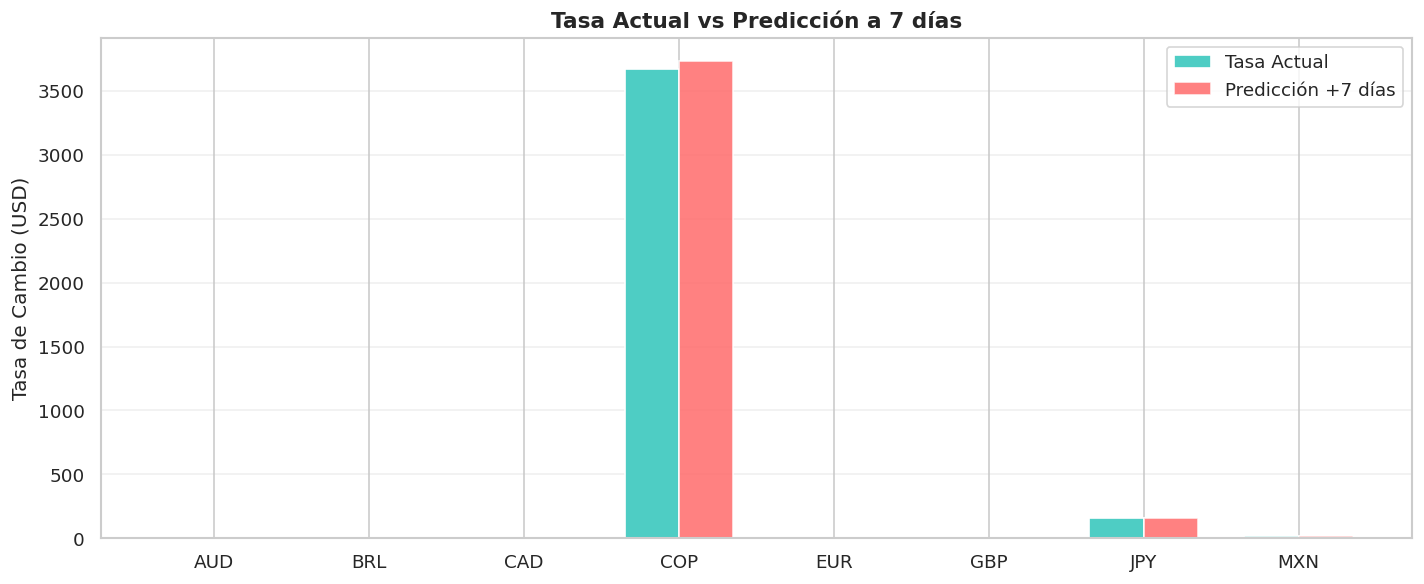


✅ Análisis ML completo


In [10]:
# CELDA 10: Predicciones a 7 días por moneda
print("🔮 PREDICCIONES A 7 DÍAS POR MONEDA")
print("="*55)

resultados = []
for moneda in df['moneda_destino'].unique():
    datos = df[df['moneda_destino'] == moneda].copy()
    X = datos[['dia']]
    y = datos['tasa_cambio']
    
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    modelo = LinearRegression()
    modelo.fit(X_tr, y_tr)
    
    dia_futuro = datos['dia'].max() + 7
    pred = modelo.predict([[dia_futuro]])[0]
    mae = mean_absolute_error(y_te, modelo.predict(X_te))
    r2  = r2_score(y_te, modelo.predict(X_te))
    
    resultados.append({
        'Moneda': moneda,
        'Tasa Actual': round(y.iloc[-1], 4),
        'Pred. +7 días': round(pred, 4),
        'Cambio %': round((pred - y.iloc[-1]) / y.iloc[-1] * 100, 3),
        'MAE': round(mae, 4),
        'R²': round(r2, 4)
    })

res_df = pd.DataFrame(resultados).sort_values('Moneda')
print(res_df.to_string(index=False))

# Gráfica resumen
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(res_df))
w = 0.35
ax.bar(x - w/2, res_df['Tasa Actual'], w, label='Tasa Actual', color='#4ecdc4')
ax.bar(x + w/2, res_df['Pred. +7 días'], w, label='Predicción +7 días', color='#ff6b6b', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(res_df['Moneda'])
ax.set_title('Tasa Actual vs Predicción a 7 días', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Cambio (USD)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/predicciones_7dias.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Análisis ML completo")